In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import string

Get data

In [70]:
BUFFER_SIZE = 10000 
BATCH_SIZE = 1000 
NUM_EPOCHS = 3 

In [9]:
# Load the EMNIST "byclass" split
(ds_train, ds_test), ds_info = tfds.load(
    'emnist/byclass',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)

# Create a list for the 62 possible characters
mapping = list(string.digits) + list(string.ascii_uppercase) + list(string.ascii_lowercase)

def get_char_from_label(label):
    """
    Converts an integer label from the emnist/byclass dataset to its character.
    """
    if 0 <= label <= 61:
        return mapping[label]
    else:
        return "Invalid Label"

# Define the preprocessing function to correct the image orientation and normalize
def preprocess(image, label):
    # Cast to float32 and normalize to [0, 1]
    image = tf.cast(image, tf.float32) / 255.0
    # The EMNIST images in TFDS are rotated, so we need to fix it
    image = tf.image.rot90(image)
    image = tf.image.flip_up_down(image)
    # image = tf.image.flip_left_right(image)
    return image, label

# Apply the preprocessing function to the datasets
ds_train = ds_train.map(preprocess)
ds_test = ds_test.map(preprocess)

x_train, y_train = [], []
x_test, y_test   = [], []

for img, label in tfds.as_numpy(ds_train):
    x_train.append(img)
    y_train.append(label)

for img, label in tfds.as_numpy(ds_test):
    x_test.append(img)
    y_test.append(label)

x_train = np.array(x_train)
y_train = np.array(y_train)
x_test  = np.array(x_test)
y_test  = np.array(y_test)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

2025-09-18 15:42:09.738918: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


(697932, 28, 28, 1) (697932,)
(116323, 28, 28, 1) (116323,)


In [10]:
rows, cols = 28, 28

# Reshape the data into a 4D Array
x_train = x_train.reshape(x_train.shape[0], rows, cols, 1)
x_test = x_test.reshape(x_test.shape[0], rows, cols, 1)

input_shape = (rows,cols,1)

# Set type as float32 and normalize the values to [0,1]
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train = x_train / 255.0
x_test = x_test / 255.0

y_train = np.array(y_train).reshape(-1)  # shape (N,)
y_test = np.array(y_test).reshape(-1)    # shape (N,)

# Transform labels to one hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 62)
y_test = tf.keras.utils.to_categorical(y_test, 62)

Create CNN+BiLSTM+CTC model

In [32]:
# Input shape: (batch_size, height, width, channels)
input_shape = (28, 28, 1)
inputs = tf.keras.Input(shape=input_shape)

# CNN feature extractor
x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
x = layers.MaxPooling2D(pool_size=(2,2))(x)    # (14, 14, 32)
x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
x = layers.MaxPooling2D(pool_size=(2,2))(x)    # (7, 7, 64)

# Reshape CNN output to (sequence_length, feature_dim)
features = layers.Reshape((7, 7*64))(x)        # (batch, 7 steps, 448 features)

# BiLSTM layer
lstm_out = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(features)

# Add one extra class for "CTC blank"
num_classes = 63 
outputs = layers.Dense(num_classes, activation="softmax")(lstm_out)

# Define the model
model = models.Model(inputs, outputs)
model.summary()

# CTC loss function
def ctc_loss(y_true, y_pred):
    batch_size = tf.shape(y_pred)[0]
    input_length = tf.fill([batch_size, 1], tf.shape(y_pred)[1])  # all 7
    # Reshape and pad y_true to match expected shape for CTC
    y_true = tf.reshape(y_true, [-1, 1])  # Reshape to have a sequence length of 1
    padding = tf.constant([[0, 0], [0, 6]]) # Pad to sequence length 7
    y_true = tf.pad(y_true, padding, "CONSTANT", constant_values=-1)

    label_length = tf.math.count_nonzero(tf.not_equal(y_true, -1), axis=-1, keepdims=True)
    return tf.keras.backend.ctc_batch_cost(y_true, y_pred, input_length, label_length)


# Compile with CTC loss
model.compile(optimizer=tf.keras.optimizers.Adam(), loss=ctc_loss)#, metrics=['accuracy'])
# Convert one-hot labels to integer labels for CTC loss
y_train_int = np.argmax(y_train, axis=1)
y_test_int = np.argmax(y_test, axis=1)

history = model.fit(x_train, y_train_int, epochs=NUM_EPOCHS, validation_data=(x_test, y_test_int), shuffle=True)

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_4 (Reshape)             │ (None, 7, 448)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 7, 256)         │       590,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7, 63)          │        16,191 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 625,855 (2.39 MB)

 Trainable params: 625,855 (2.39 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
21811/21811 ━━━━━━━━━━━━━━━━━━━━ 603s 28ms/step - loss: 1.0377 - val_loss: 0.4360
Epoch 2/3
21811/21811 ━━━━━━━━━━━━━━━━━━━━ 550s 25ms/step - loss: 0.4100 - val_loss: 0.3916
Epoch 3/3
21811/21811 ━━━━━━━━━━━━━━━━━━━━ 580s 27ms/step - loss: 0.3773 - val_loss: 0.3795


Get sample set

Training Data (697932, 28, 28) (697932, 62)
Test Data (116323, 28, 28) (116323, 62)


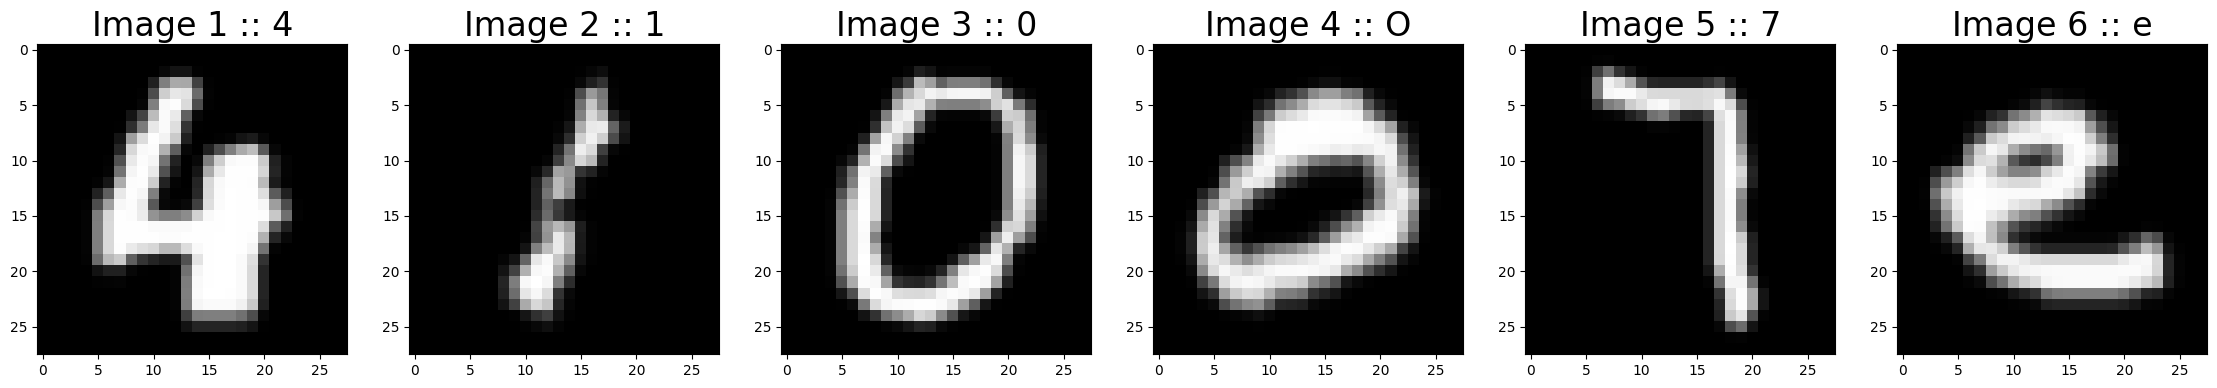

In [73]:
x_train = x_train.reshape(x_train.shape[0], 28,28)
print('Training Data', x_train.shape, y_train.shape)
x_test = x_test.reshape(x_test.shape[0], 28,28)
print('Test Data', x_test.shape, y_test.shape)

# Plot the Image
DUMMY_BATCH_SIZE = 6
image_index = np.random.randint(0, x_test.shape[0], size=DUMMY_BATCH_SIZE)
dummy_batch = x_test[image_index]
true_labels = [get_char_from_label(np.argmax(y_test[idx])) for idx in image_index]

fig, axes = plt.subplots(1, DUMMY_BATCH_SIZE, figsize=(28, 28))
for i in range(DUMMY_BATCH_SIZE):
    axes[i].imshow(dummy_batch[i], cmap='gray')
    axes[i].set_title(f"Image {i+1} :: {true_labels[i]}", fontsize=24)


Show CNN output

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
CNN features shape: (6, 7, 448)


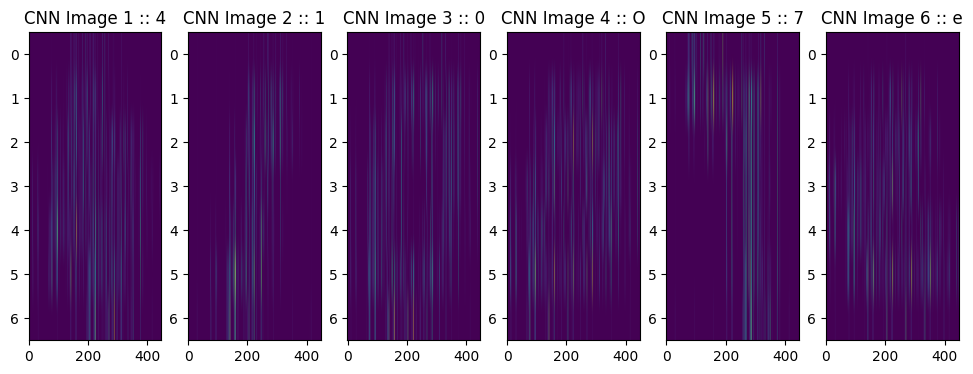

In [81]:

# Get CNN features for dummy_images
cnn_model = models.Model(inputs, features)
# cnn_model = models.Model(inputs, x)
cnn_features = cnn_model.predict(dummy_batch)

print("CNN features shape:", cnn_features.shape)
fig, axes = plt.subplots(1, DUMMY_BATCH_SIZE, figsize=(12, 4))
for i in range(DUMMY_BATCH_SIZE):
    # Show the mean across channels for visualization
    # axes[i].imshow(np.mean(cnn_features[i], axis=-1), cmap='viridis')
    axes[i].imshow(cnn_features[i], aspect='auto', cmap='viridis')
    axes[i].set_title(f"CNN Image {i+1} :: {true_labels[i]}")



Show BiLSTM output

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
BiLSTM features shape: (6, 7, 256)


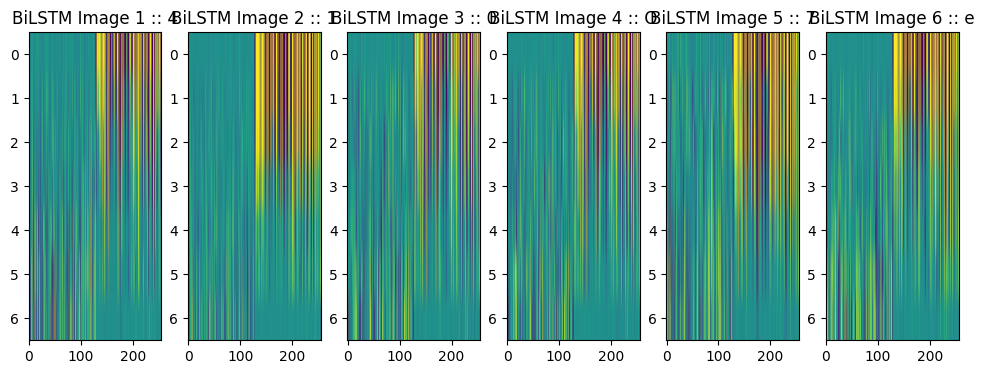

In [82]:
biLSTM = models.Model(inputs, lstm_out)
biLSTM_features = biLSTM.predict(dummy_batch)

print("BiLSTM features shape:", biLSTM_features.shape)
fig, axes = plt.subplots(1, DUMMY_BATCH_SIZE, figsize=(12, 4))
for i in range(DUMMY_BATCH_SIZE):
    # Show the BiLSTM output as a heatmap: shape (7, 11)
    axes[i].imshow(biLSTM_features[i], aspect='auto', cmap='viridis')
    axes[i].set_title(f"BiLSTM Image {i+1} :: {true_labels[i]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
Full output shape: (6, 7, 63)


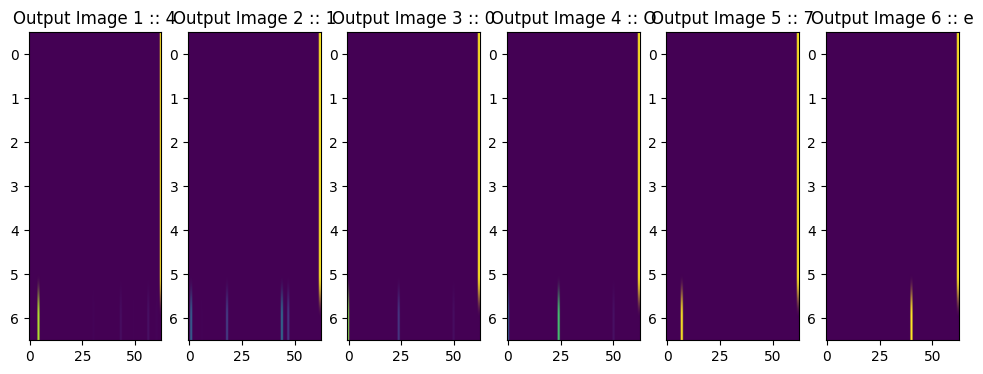

In [83]:
output_model = models.Model(inputs, outputs)
output_features = output_model.predict(dummy_batch)

print("Full output shape:", output_features.shape)
fig, axes = plt.subplots(1, DUMMY_BATCH_SIZE, figsize=(12, 4))
for i in range(DUMMY_BATCH_SIZE):
    axes[i].imshow(output_features[i], aspect='auto', cmap='viridis')
    axes[i].set_title(f"Output Image {i+1} :: {true_labels[i]}")

decoded preds :: log prob
[SparseTensor(indices=tf.Tensor(
[[0 0]
 [1 0]
 [2 0]
 [3 0]
 [4 0]
 [5 0]], shape=(6, 2), dtype=int64), values=tf.Tensor([ 4 44  0 24  7 40], shape=(6,), dtype=int64), dense_shape=tf.Tensor([6 1], shape=(2,), dtype=int64))] tf.Tensor(
[[0.13156727]
 [1.0796071 ]
 [0.20727645]
 [0.35024562]
 [0.00438817]
 [0.00141106]], shape=(6, 1), dtype=float32)

decoded preds dense
tf.Tensor(
[[ 4]
 [44]
 [ 0]
 [24]
 [ 7]
 [40]], shape=(6, 1), dtype=int64)

to numpy :: [[ 4]
 [44]
 [ 0]
 [24]
 [ 7]
 [40]]
to flatten :: [ 4 44  0 24  7 40]
predicted digits ::  [4, 44, 0, 24, 7, 40]
['4', 'i', '0', 'O', '7', 'e']


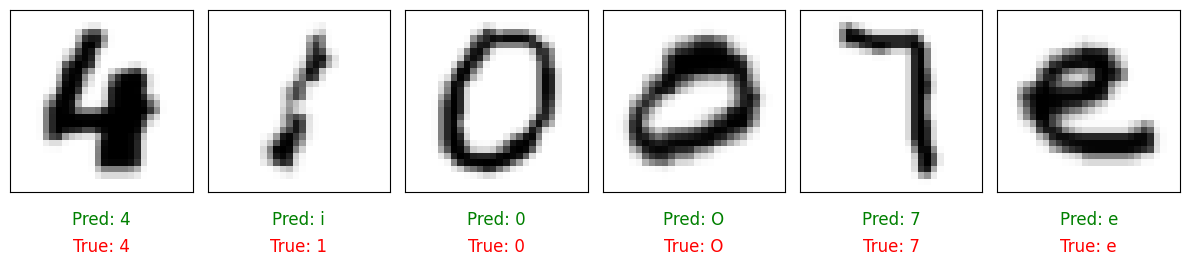

In [84]:
raw_preds = output_features

# Perform CTC decoding using tf.nn.ctc_greedy_decoder
# tf.nn.ctc_greedy_decoder expects inputs with shape [time_steps, batch_size, num_classes]
# Our model output has shape [batch_size, time_steps, num_classes], so we need to transpose it.
transposed_preds = tf.transpose(raw_preds, perm=[1, 0, 2])

# tf.nn.ctc_greedy_decoder also expects log probabilities.
log_probs = tf.math.log(transposed_preds + tf.keras.backend.epsilon())

# The `sequence_length` is the length of the sequence for each example in the batch.
batch_size = tf.shape(raw_preds)[0]
input_length = tf.fill([batch_size], tf.shape(raw_preds)[1]) # all 7

# Perform CTC greedy decoding
decoded_preds, log_prob = tf.nn.ctc_greedy_decoder(log_probs, input_length)
print("decoded preds :: log prob")
print(decoded_preds, log_prob)
print()

# The output of ctc_greedy_decoder is a list of sparse tensors.
# Convert the sparse tensor to a dense tensor for easier handling.
decoded_preds_dense = tf.sparse.to_dense(decoded_preds[0], default_value=-1)
print("decoded preds dense")
print(decoded_preds_dense)
print()

# Turn to actual workable list
print(f"to numpy :: {decoded_preds_dense.numpy()}\nto flatten :: {decoded_preds_dense.numpy().flatten()}" )
predicted_digits = decoded_preds_dense.numpy().flatten().tolist()
print("predicted digits :: ", predicted_digits)


print([get_char_from_label(x) for x in predicted_digits])

# Display images with decoded predictions
fig = plt.figure(figsize=(12, 8)) # Adjust figure size for better display
for i in range(DUMMY_BATCH_SIZE):
    ax = fig.add_subplot(2, 6, i + 1)
    ax.set_xticks([])
    ax.set_yticks([])
    img = dummy_batch[i]
    ax.imshow(img, cmap='gray_r')
    # Display the decoded digit
    ax.text(0.5, -0.15, 'Pred: {}'.format(get_char_from_label(predicted_digits[i])), size=12, color='green',
            horizontalalignment='center', verticalalignment='center',
            transform=ax.transAxes)

    # Optionally display the true label for comparison
    ax.text(0.5, -0.3, 'True: {}'.format(true_labels[i]), size=12, color='red',
            horizontalalignment='center', verticalalignment='center',
            transform=ax.transAxes)

plt.tight_layout() # Adjust layout to prevent overlapping
plt.show()
